In [15]:
!pip install --upgrade openai


/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
Defaulting to user installation because normal site-packages is not writeable


In [35]:
from config import OPENAI_API_KEY
import openai
from openai import OpenAI

# ----------------------------
# CONFIGURATION AND CONSTANTS
# ----------------------------
MODEL_NAME = "gpt-4o"
MAX_TURNS = 5

CLIMATE_SUMMARIES = {
    "Argyre": "Experiences extreme weather events that would delay climate modeling. "
              "Sensing equipment would need to be dismantled frequently, making the project take 2-3 times longer.",
    "Casius": "May hold key insights into irreversible climate change. Provides data that could help understand "
              "climate change dynamics on Earth.",
    "Diacria": "Has very consistent, non-variable climate conditions. Would take 10+ years to build an accurate "
               "climate model due to lack of atmospheric fluctuations.",
    "Eridania": "Climate has been extensively mapped by Curiosity rover. Contains fascinating cloud patterns that "
                "could unlock secrets of Martian climate."
}

LIFE_SCIENCE_SUMMARIES = {
    "Argyre": "No evidence of surface lakes or streams. Unlikely to find fossils in dusty sands.",
    "Casius": "High methane concentrations suggest potential for living organisms. Evidence of a subglacial lake "
              "makes it a top priority for finding life.",
    "Diacria": "Trace methane amounts make it disappointing for life discovery. However, potential hydrothermal "
               "pools and subsurface water reservoir exist.",
    "Eridania": "Found complex organic compounds in mudstone rocks similar to those associated with microbial life "
                "on Earth. Very cold, reducing life probability."
}

GEOLOGY_SUMMARIES = {
    "Argyre": "Boring geological landscape. However, nearby is an immense canyon system extending a quarter of the planet's circumference.",
    "Casius": "Porous surface ideal for core exploration. Experiences mild earthquakes. No nearby volcanoes of interest.",
    "Diacria": "Contains three enormous volcanoes. Provides unique access to tectonic and core data. Many unmapped surface areas.",
    "Eridania": "Difficult to collect rock samples due to solid stone upper crust. Rich in impact craters, offering insights into Mars' geological history."
}


def climate_scientist_goals():
    return """Your role is the Climate Scientist. Your goals:
1. Determine if life exists or ever existed on Mars.
2. Understand the geology of Mars.
3. Understand the atmosphere and climate dynamics on Mars.
Remember: Scientific Discovery, Life, Geology, Climate
"""


def life_scientist_goals():
    return """Your role is the Life Scientist. Your goals:
1. Determine if life exists or ever existed on Mars.
2. Understand the geology of Mars.
3. Understand the atmosphere and climate dynamics on Mars.
Remember: Scientific Discovery, Life, Geology, Climate
"""


def geology_scientist_goals():
    return """Your role is the Geology Scientist. Your goals:
1. Determine if life exists or ever existed on Mars.
2. Understand the geology of Mars.
3. Understand the atmosphere and climate dynamics on Mars.
Remember: Scientific Discovery, Life, Geology, Climate
"""


# Agent configuration
AGENTS = {
    "climate": {
        "role": "Climate Scientist",
        "goals": climate_scientist_goals(),
        "summaries": CLIMATE_SUMMARIES,
        "decider_instructions": "You are the climate scientist. Decide if you have more to contribute or if you should give a final answer. If the conversation seems near conclusion, finalize your answer.",
        "conversation_instructions": "You are the climate scientist. Discuss possible landing sites focusing on climate feasibility and advantages or disadvantages of each location."
    },
    "life": {
        "role": "Life Scientist",
        "goals": life_scientist_goals(),
        "summaries": LIFE_SCIENCE_SUMMARIES,
        "decider_instructions": "You are the life scientist. Decide if you have more to contribute or if you should finalize your recommendation. If you believe the conversation is near a decision point, finalize.",
        "conversation_instructions": "You are the life scientist. Discuss what sites have the highest potential for discovering life. Focus on methane, organic compounds, and water."
    },
    "geology": {
        "role": "Geology Scientist",
        "goals": geology_scientist_goals(),
        "summaries": GEOLOGY_SUMMARIES,
        "decider_instructions": "You are the geology scientist. Decide if you have more to contribute or if you should finalize your recommendation. If the conversation seems conclusive, finalize.",
        "conversation_instructions": "You are the geology scientist. Discuss which site offers the best geological research opportunities. Highlight volcanoes, tectonics, and crater analysis."
    }
}


# Initialize the OpenAI client
client = OpenAI(api_key=OPENAI_API_KEY)


def call_openai_model(messages, model=MODEL_NAME, temperature=0.7):
    """
    Calls the OpenAI chat completion model with the given messages.
    """
    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=temperature
    )
    return response.choices[0].message.content


def transform_history_for_agent(agent_key, conversation_history):
    """
    Transform the conversation history from the perspective of the current agent:
    - system messages remain "system"
    - messages from this agent become "assistant"
    - messages from other agents become "user"
    """
    transformed = []
    for msg in conversation_history:
        if msg["role"] == "system":
            transformed.append({"role": "system", "content": msg["content"]})
        else:
            if msg.get("name") == agent_key:
                # Current agent's own previous messages are assistant messages
                transformed.append({"role": "assistant", "content": msg["content"]})
            else:
                # All other agents' messages become user messages
                transformed.append({"role": "user", "content": msg["content"]})
    return transformed


def agent_decider(agent_key, conversation_history):
    """
    The decider model: decides if the agent should continue contributing or finalize.
    Returns either 'CONTRIBUTE' or 'FINALIZE'.
    """
    agent_data = AGENTS[agent_key]
    recent_history = conversation_history[-10:]

    # Construct prompt
    prompt = [
        {"role": "system", "content": agent_data["goals"]},
        {"role": "system", "content": agent_data["decider_instructions"]},
        {"role": "user", "content": "Given the conversation so far, should you contribute more or finalize your recommendation? Respond ONLY with 'CONTRIBUTE' or 'FINALIZE'."}
    ]

    transformed_history = transform_history_for_agent(agent_key, recent_history)
    prompt.extend(transformed_history)

    decision = call_openai_model(prompt, model=MODEL_NAME, temperature=0.0)
    return "FINALIZE" if "FINALIZE" in decision.upper() else "CONTRIBUTE"


def agent_conversation(agent_key, conversation_history, finalize=False):
    """
    The conversation model for the agent: either continue discussion or provide a final answer.
    """
    agent_data = AGENTS[agent_key]

    # User message depends on whether we are finalizing or not
    user_message = "Please provide your final recommended landing site and a brief justification." if finalize else \
        "Please continue the discussion considering the other scientists' points."

    # Select summaries based on agent role
    if agent_key == "climate":
        summaries_content = f"Climate:\n{CLIMATE_SUMMARIES}"
    elif agent_key == "life":
        summaries_content = f"Life:\n{LIFE_SCIENCE_SUMMARIES}"
    elif agent_key == "geology":
        summaries_content = f"Geology:\n{GEOLOGY_SUMMARIES}"
    else:
        summaries_content = "No summaries available."

    transformed_history = transform_history_for_agent(agent_key, conversation_history)

    prompt = [
        {"role": "system", "content": agent_data["goals"]},
        {"role": "system", "content": agent_data["conversation_instructions"]},
        {"role": "system", "content": f"Here are location-specific summaries:\n{summaries_content}"},
        {"role": "system", "content": "You are part of a team of three scientists (climate, life, geology). "
                                      "The conversation is about choosing the best landing site on Mars for your mission. "
                                      "Keep your replies short. Talk only from your perspective."}
    ]
    prompt.extend(transformed_history)
    prompt.append({"role": "user", "content": user_message})

    return call_openai_model(prompt, model=MODEL_NAME, temperature=0.7)


def run_conversation(MAX_TURNS = 10):
    """
    Run a round-robin conversation among the three agents until all finalize or max turns reached.
    """
    conversation_history = []
    finalized = {"climate": False, "life": False, "geology": False}

    # Initial system prompt
    conversation_history.append({
        "role": "system",
        "content": "You are three scientists discussing where to land on Mars. "
                   "Consider climate, life potential, and geology to select the best site. Start the conversation now."
    })

    agent_order = ["climate", "life", "geology"]
    turn = 0

    while turn < MAX_TURNS:
        # If all have finalized, stop
        if all(finalized.values()):
            break

        for agent_key in agent_order:
            # Skip agents that have already finalized
            if finalized[agent_key]:
                continue

            decision = agent_decider(agent_key, conversation_history)
            if decision == "FINALIZE":
                response = agent_conversation(agent_key, conversation_history, finalize=True)
                finalized[agent_key] = True
            else:
                response = agent_conversation(agent_key, conversation_history, finalize=False)

            conversation_history.append({"role": "assistant", "name": agent_key, "content": response})

            if decision == "FINALIZE":
                finalized[agent_key] = True

        turn += 1

    return conversation_history

In [36]:
final_conversation = run_conversation(MAX_TURNS = 10)

In [39]:
def extract_final_choice(conversation):
    """
    After the conversation ends, call the EXTRACTOR agent to determine the team's final chosen location.
    The EXTRACTOR should respond with one word: the chosen location or 'ERROR' if unclear.
    """

    # We'll just feed the entire conversation to the model and ask for a single-word summary.
    # The conversation includes system, assistant messages from each agent.
    # We trust that by the end of the conversation, a final decision was made.

    # Transform the entire final conversation so the EXTRACTOR sees them as a single user-provided text.
    # The EXTRACTOR is a separate "system" persona with a simple rule.
    conversation_content = ""
    for msg in conversation:
        # We'll just include all messages. The EXTRACTOR should figure out the final location.
        # It's safe to give them all in user role so it tries to extract from user perspective.
        # Or we can just present them as assistant content one after another.
        conversation_content += f"{msg.get('name', msg['role']).upper()}: {msg['content']}\n\n"

    extractor_prompt = [
        {"role": "system", "content": "You are the EXTRACTOR agent. You will read the entire conversation and determine the final chosen landing location on Mars."},
        {"role": "system", "content": "Output only one word: the chosen site name (e.g., 'Casius', 'Argyre', 'Diacria', 'Eridania') if a single final choice is clear. Otherwise, output 'ERROR'."},
        {"role": "user", "content": "Here is the entire conversation:\n" + conversation_content}
    ]

    response = call_openai_model(extractor_prompt, model=MODEL_NAME, temperature=0.0)
    # Just in case, strip whitespace
    final_choice = response.strip()
    # Ensure it's one word or 'ERROR'
    # If not sure, return 'ERROR'
    if final_choice not in ["Argyre", "Casius", "Diacria", "Eridania", "ERROR"]:
        final_choice = "ERROR"
    return final_choice

In [41]:
final_conversation

[{'role': 'system',
  'content': 'You are three scientists discussing where to land on Mars. Consider climate, life potential, and geology to select the best site. Start the conversation now.'},
 {'role': 'assistant',
  'name': 'climate',
  'content': "From a climate perspective, here are my thoughts on the potential landing sites:\n\n1. **Argyre**: Though it presents extreme weather events, studying these could offer insights into Martian climate variability and atmospheric dynamics. However, expect delays due to the need to frequently dismantle and reassemble sensing equipment.\n\n2. **Casius**: This site offers a unique opportunity to study potential irreversible climate change, which could parallel shifts seen on Earth. It could provide valuable data on climate change dynamics.\n\n3. **Diacria**: While the climate is stable, the lack of variability means it would take a long time to build a comprehensive climate model. Not ideal for quick insights but good for long-term stability s

In [40]:
extract_final_choice(final_conversation[-3:])

'Casius'

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming run_conversation() and extract_final_choice() are defined as in previous code

final_choices = []
num_simulations = 10

for i in range(num_simulations):
    final_conversation = run_conversation()
    choice = extract_final_choice(final_conversation)
    final_choices.append(choice)
    print(f"{i}. {choice}")

KeyboardInterrupt: 

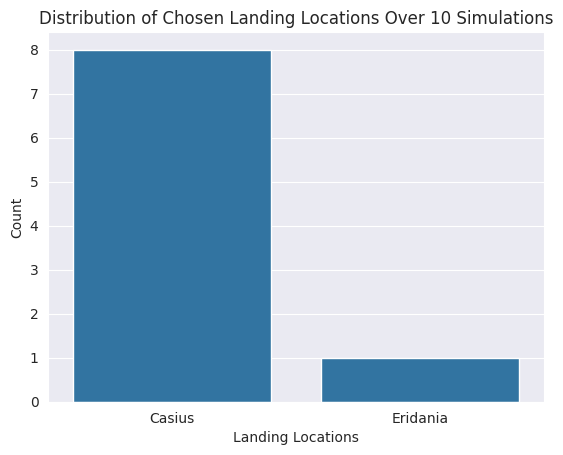

In [44]:
final_choices
sns.countplot(x=final_choices)
plt.xlabel("Landing Locations")
plt.ylabel("Count")
plt.title("Distribution of Chosen Landing Locations Over 10 Simulations")
plt.show()

In [1]:
import asyncio
from config import OPENAI_API_KEY
import openai
from openai import AsyncOpenAI
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# CONFIGURATION AND CONSTANTS
# ----------------------------
openai.api_key = OPENAI_API_KEY
MODEL_NAME = "gpt-4o-mini"

# Templates for instructions
GOALS_TEMPLATE = {
    "Scientist": """Your role is the {role_mts}. Your goals:
    These are the factors you need to consider when deciding which location will best
support the Mars science goals:
1. Maximize chances for scientific discoveries
2. Determine if life exists or ever existed on Mars.
3. Understand the geology of Mars.
4. Understand the atmosphere and climate dynamics on Mars.
5. Consider perspectives of others and find location that is good for both scientific discoveries and habitation support.
Remember: Scientific Discovery, Life, Geology, Climate.
Be more mindful about others. the goal of the collaboration is to select landing location that will benefit the whole mission.
""",
    "Specialist": """Your role is the {role_mts}. Your goals:
    These are factors you need to consider when deciding which location will best support human habitation on Mars:
1. Safely landing on Mars, and receiving re-supply capsules.
2. Access to sunlight to power solar arrays, and favorable atmospheric conditions for breathing.
3. Habitat and other terrain that will protect humans from the harsh environment.
4. Access to water and other resources needed for survival.
5. Consider perspectives of others and find location that is good for both scientific discoveries and habitation support.
Remember: Human Habitation, Atmosphere, Terrain, Water
Be more mindful about others. the goal of the collaboration is to select landing location that will benefit the whole mission.
"""
}


DECIDER_INSTRUCTIONS_TEMPLATE = "You are the {role_mts}. Decide if you have more to contribute or finalize your answer. Respond 'CONTRIBUTE' or 'FINALIZE'."
CONVERSATION_INSTRUCTIONS_TEMPLATE = "You are the {role_mts}. Discuss the best landing site on Mars given your domain expertise."

AGENTS = {
    "climate": {
        "role_mts": "Climate Scientist",
        "summaries": {
            "Climate": {
                "Argyre": "Experiences extreme weather events that would delay climate modeling. Sensing equipment would need to be dismantled frequently, making the project take 2-3 times longer.",
                "Casius": "May hold key insights into irreversible climate change. Provides data that could help understand climate change dynamics on Earth.",
                "Diacria": "Has very consistent, non-variable climate conditions. Would take 10+ years to build an accurate climate model due to lack of atmospheric fluctuations.",
                "Eridania": "Climate has been extensively mapped by Curiosity rover. Contains fascinating cloud patterns that could unlock secrets of Martian climate."
            }
        }
    },
    "life": {
        "role_mts": "Life Scientist",
        "summaries": {
            "Life": {
                "Argyre": "No evidence of surface lakes or streams. Unlikely to find fossils in dusty sands.",
                "Casius": "High methane concentrations suggest potential for living organisms. Evidence of a subglacial lake makes it a top priority for finding life.",
                "Diacria": "Trace methane amounts make it disappointing for life discovery. However, potential hydrothermal pools and subsurface water reservoir exist.",
                "Eridania": "Found complex organic compounds in mudstone rocks similar to those associated with microbial life on Earth. Very cold, reducing life probability."
            }
        }
    },
    "geology": {
        "role_mts": "Geology Scientist",
        "summaries": {
            "Geology": {
                "Argyre": "Boring geological landscape. However, nearby is an immense canyon system extending a quarter of the planet's circumference.",
                "Casius": "Porous surface ideal for core exploration. Experiences mild earthquakes. No nearby volcanoes of interest.",
                "Diacria": "Contains three enormous volcanoes. Provides unique access to tectonic and core data. Many unmapped surface areas.",
                "Eridania": "Difficult to collect rock samples due to solid stone upper crust. Rich in impact craters, offering insights into Mars' geological history."
            }
        }
    },
    "water": {
        "role_mts": "Water Specialist",
        "summaries": {
            "Water": {
                "Argyre": "Subglacial lake accessible but challenges in contamination and power requirements. Most sunlight for energy.",
                "Casius": "Deep water reserves difficult to access. Low sunlight and high cosmic radiation risks.",
                "Diacria": "Long replenishment times for water reserves. Toxic chlorine in water requires energy-intensive dechlorination.",
                "Eridania": "High water reserves but limited sunlight and buried glacial ice increases harvesting difficulty."
            }
        }
    },
    "terrain": {
        "role_mts": "Terrain Specialist",
        "summaries": {
            "Terrain": {
                "Argyre": "Flat terrain ideal for landing and high sunlight exposure. Challenges in mining subglacial water.",
                "Casius": "High elevation complicates landing and living conditions. Limited water reserves accessible.",
                "Diacria": "Ideal for underground habitats and lava tube exploration. Toxic chlorine in soil and water purification challenges.",
                "Eridania": "Solid stone crust increases challenges for habitat construction and water access. High water reserves available."
            }
        }
    },
    "atmosphere": {
        "role_mts": "Atmospheric Specialist",
        "summaries": {
            "Atmosphere": {
                "Argyre": "Favorable atmospheric conditions for air production. Most sunlight for energy systems.",
                "Casius": "Extreme temperature fluctuations limit air production capabilities. Low sunlight hinders energy harvesting.",
                "Diacria": "Optimal atmospheric carbon dioxide levels for air production. Low elevation aids in landings.",
                "Eridania": "High particulate matter disrupts air production systems. Limited sunlight for energy harvesting."
            }
        }
    }
}

In [2]:
client = AsyncOpenAI(api_key=OPENAI_API_KEY)

async def call_openai_model(messages, model=MODEL_NAME, temperature=0.7):
    response = await client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=temperature
    )
    return response.choices[0].message.content

def transform_history_for_agent(agent_key, conversation_history):
    """
    Transform the conversation history from the perspective of the current agent:
    - system messages remain "system"
    - messages from this agent become "assistant"
    - messages from other agents become "user"
    """
    transformed = []
    for msg in conversation_history:
        if msg["role"] == "system":
            transformed.append({"role": "system", "content": msg["content"]})
        else:
            if msg.get("name") == agent_key:
                transformed.append({"role": "assistant", "content": msg["content"]})
            else:
                transformed.append({"role": "user", "content": msg["content"]})
    return transformed

def get_agent_instructions(agent_key, agents):
    """
    Given an agent key, produce the goals, decider_instructions, and conversation_instructions
    by formatting the templates with the agent's role_mts.
    """
    role_mts = agents[agent_key]["role_mts"]

    if "Scientist" in role_mts:
        goals = GOALS_TEMPLATE['Scientist'].format(role_mts=role_mts)
    if "Specialist" in role_mts:
        goals = GOALS_TEMPLATE['Specialist'].format(role_mts=role_mts)

    decider_instructions = DECIDER_INSTRUCTIONS_TEMPLATE.format(role_mts=role_mts)
    conversation_instructions = CONVERSATION_INSTRUCTIONS_TEMPLATE.format(role_mts=role_mts)
    return goals, decider_instructions, conversation_instructions

async def agent_decider(agent_key, agents, conversation_history):
    """
    Decide if the agent should continue or finalize.
    """
    goals, decider_instructions, _ = get_agent_instructions(agent_key, agents)
    recent_history = conversation_history[-10:]
    prompt = [
        {"role": "system", "content": goals},
        {"role": "system", "content": decider_instructions},
        {"role": "user", "content": "Should you contribute more or finalize? Respond 'CONTRIBUTE' or 'FINALIZE'."}
    ]

    transformed_history = transform_history_for_agent(agent_key, recent_history)
    prompt.extend(transformed_history)

    decision = await call_openai_model(prompt, model=MODEL_NAME, temperature=0.0)
    return "FINALIZE" if "FINALIZE" in decision.upper() else "CONTRIBUTE"

async def agent_conversation(agent_key, agents, conversation_history, finalize=False):
    """
    Agent produces either more discussion or a final answer.
    """
    goals, _, conversation_instructions = get_agent_instructions(agent_key, agents)
    agent_data = agents[agent_key]
    user_message = "Please provide your final recommended landing site and a brief justification." if finalize \
        else "Please continue the discussion considering the other scientists' points."

    # Construct summaries message
    combined_summaries = ""
    for summary_type, summary_dict in agent_data["summaries"].items():
        combined_summaries += f"{summary_type}:\n{summary_dict}\n"

    transformed_history = transform_history_for_agent(agent_key, conversation_history)

    prompt = [
        {"role": "system", "content": goals},
        {"role": "system", "content": conversation_instructions},
        {"role": "system", "content": f"Here are location-specific summaries:\n{combined_summaries}"},
        {"role": "system", "content": "You are part of a team of scientists discussing the best landing site on Mars. Keep replies short. Talk only from your perspective."}
    ]
    prompt.extend(transformed_history)
    prompt.append({"role": "user", "content": user_message})

    return await call_openai_model(prompt, model=MODEL_NAME, temperature=0.7)

async def run_conversation(agents, MAX_TURNS=10):
    """
    Run a round-robin conversation among the given agents until all finalize or max turns reached.
    """
    conversation_history = []
    finalized = {agent_key: False for agent_key in agents.keys()}

    # Initial system prompt
    conversation_history.append({
        "role": "system",
        "content": "You are a team of scientists discussing where to land on Mars. Consider all factors. Start now."
    })

    agent_order = list(agents.keys())
    turn = 0

    while turn < MAX_TURNS:
        if all(finalized.values()):
            break

        for agent_key in agent_order:
            if finalized[agent_key]:
                continue

            decision = await agent_decider(agent_key, agents, conversation_history)
            if decision == "FINALIZE":
                response = await agent_conversation(agent_key, agents, conversation_history, finalize=True)
                finalized[agent_key] = True
            else:
                response = await agent_conversation(agent_key, agents, conversation_history, finalize=False)

            conversation_history.append({"role": "assistant", "name": agent_key, "content": response})
            if decision == "FINALIZE":
                finalized[agent_key] = True

        turn += 1

    return conversation_history

async def extract_final_choice(conversation):
    """
    Extract final chosen landing location or 'ERROR'.
    """
    conversation_content = ""
    for msg in conversation:
        conversation_content += f"{msg.get('name', msg['role']).upper()}: {msg['content']}\n"

    extractor_prompt = [
        {"role": "system", "content": "You are the EXTRACTOR. Determine final chosen landing site from the conversation."},
        {"role": "system", "content": "Output only one word: 'Argyre', 'Casius', 'Diacria', 'Eridania', or 'ERROR'."},
        {"role": "user", "content": f"CONVERSATION:\n{conversation_content}"}
    ]

    response = await call_openai_model(extractor_prompt, model=MODEL_NAME, temperature=0.0)
    final_choice = response.strip()
    if final_choice not in ["Argyre", "Casius", "Diacria", "Eridania"]:
        final_choice = "ERROR"
    return final_choice

async def run_single_simulation(i, agents):
    conv = await run_conversation(agents, MAX_TURNS=15)
    choice = await extract_final_choice(conv)
    print(f"simulation {i}, choice: {choice}")
    return choice




In [90]:
MODEL_NAME = "gpt-4o-mini"
await run_single_simulation(1, agents_specialists)

CancelledError: 

In [91]:
agents_science = {key: value for key, value in AGENTS.items() if key in ["climate", "life", "geology"]}
agents_specialists = {key: value for key, value in AGENTS.items() if key in ["water", "terrain", "atmosphere"]}

In [3]:
async def run_n_simulations(num_simulations = 10, agents = AGENTS):
    # Run simulations in parallel
    results = await asyncio.gather(*(run_single_simulation(i, agents) for i in range(num_simulations)))
    print("All simulations complete:")
    print(results)

In [10]:
MODEL_NAME = "gpt-4o"
mts_results = await run_n_simulations(num_simulations = 5, agents = AGENTS)

simulation 1, choice: Diacria
simulation 2, choice: Eridania
simulation 0, choice: Casius
simulation 3, choice: Argyre
simulation 4, choice: Casius
All simulations complete:
['Casius', 'Diacria', 'Eridania', 'Argyre', 'Casius']


In [9]:
mts_results

None


In [ ]:
['Argyre', 'Argyre', 'Argyre', 'Argyre', 'Argyre', 'Casius', 'Casius', 'Casius', 'Casius', 'Casius', 'Casius']

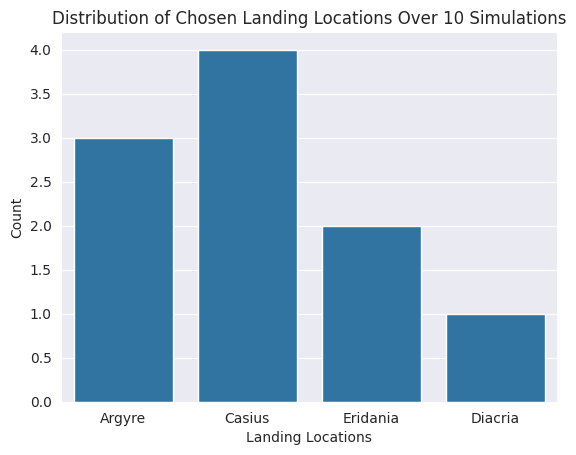

In [11]:
# Create a bar chart of final choices
sns.countplot(x=['Argyre', 'Casius', 'Eridania', 'Casius', 'Argyre', 'Casius', 'Diacria', 'Eridania', 'Argyre', 'Casius'])
plt.xlabel("Landing Locations")
plt.ylabel("Count")
plt.title("Distribution of Chosen Landing Locations Over 10 Simulations")
plt.show()